
Tuning LR...
Accuracy: 0.9737
Best Params: {'logisticregression__C': 0.1}
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Tuning RF...
Accuracy: 0.9561
Best Params: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__n_estimators': 100}
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Tuning XGB...
Accuracy: 0.9474
Best Params: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__n_estimators': 100}
              preci

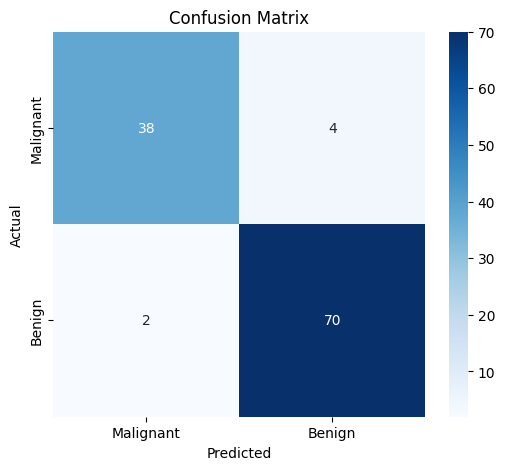

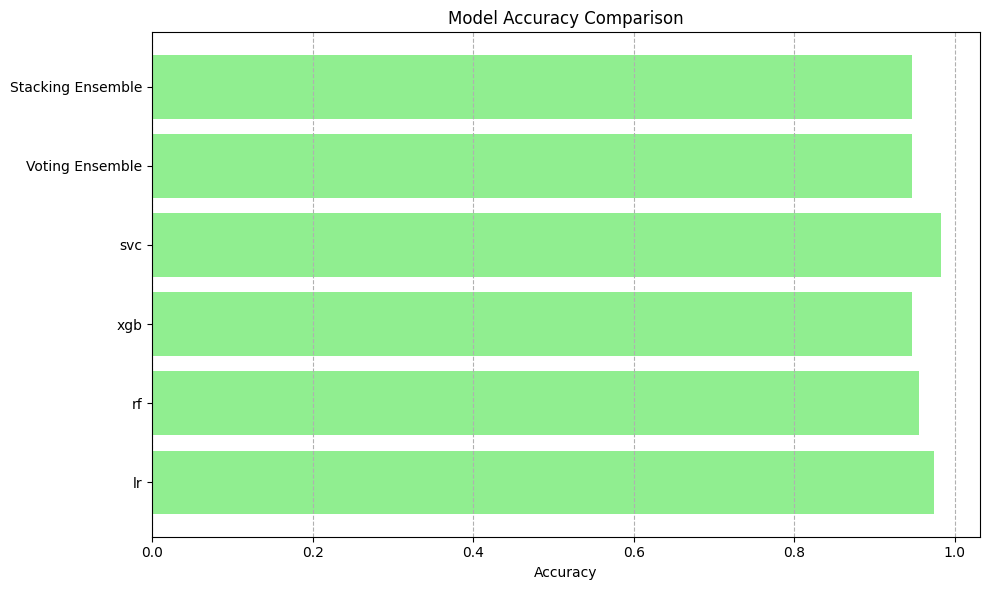

In [1]:

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Parameter Grids
param_grids = {

    'lr': {
        'logisticregression__C': [0.1, 1, 10]
    },

    'rf': {
        'randomforestclassifier__n_estimators': [50, 100],
        'randomforestclassifier__max_depth': [3, 5, None]
    },

    'xgb': {
        'xgbclassifier__n_estimators': [50, 100],
        'xgbclassifier__learning_rate': [0.01, 0.1, 0.3]
    },

    'svc': {
        'svc__C': [0.1, 1],
        'svc__kernel': ['linear', 'rbf']
    }
}

# Pipelines
pipelines = {

    'lr': make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=42)
    ),

    'rf': make_pipeline(
        StandardScaler(),
        RandomForestClassifier(random_state=42)
    ),

    'xgb': make_pipeline(
        StandardScaler(),
        XGBClassifier(
            eval_metric='logloss',
            random_state=42
        )
    ),

    'svc': make_pipeline(
        StandardScaler(),
        SVC(
            probability=True,
            random_state=42
        )
    )
}

best_models = {}
accuracies = {}

# Hyperparameter Tuning
for name, pipe in pipelines.items():

    print(f"\nTuning {name.upper()}...")

    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring='accuracy'
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    pred = grid.predict(X_test)

    acc = accuracy_score(y_test, pred)

    accuracies[name] = acc

    print(f"Accuracy: {acc:.4f}")
    print("Best Params:", grid.best_params_)

    print(classification_report(y_test, pred))

# Voting Ensemble
voting_clf = VotingClassifier(

    estimators=[
        ('lr', best_models['lr']),
        ('rf', best_models['rf']),
        ('xgb', best_models['xgb']),
        ('svc', best_models['svc'])
    ],

    voting='soft'
)

voting_clf.fit(X_train, y_train)

voting_pred = voting_clf.predict(X_test)

voting_acc = accuracy_score(y_test, voting_pred)

accuracies['Voting Ensemble'] = voting_acc

print("\nVoting Ensemble Accuracy:", voting_acc)

# Stacking Ensemble
stack_clf = StackingClassifier(

    estimators=[
        ('lr', best_models['lr']),
        ('rf', best_models['rf']),
        ('xgb', best_models['xgb'])
    ],

    final_estimator=LogisticRegression()
)

stack_clf.fit(X_train, y_train)

stack_pred = stack_clf.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)

accuracies['Stacking Ensemble'] = stack_acc

print("\nStacking Ensemble Accuracy:", stack_acc)

# Select Best Ensemble Model
if stack_acc >= voting_acc:
    final_best_model = stack_clf
    selected_model = "Stacking Ensemble"
else:
    final_best_model = voting_clf
    selected_model = "Voting Ensemble"

print(f"\nBest Ensemble Model: {selected_model}")

# Cross Validation
cv_scores = cross_val_score(
    final_best_model,
    X,
    y,
    cv=5
)

print("\nCross Validation Accuracy:", cv_scores.mean())

# Save Model
with open('best_ensemble_model.pkl', 'wb') as f:
    pickle.dump(final_best_model, f)

print("\n✅ Model Saved Successfully")

# Confusion Matrix
cm = confusion_matrix(y_test, final_best_model.predict(X_test))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Accuracy Comparison Plot
plt.figure(figsize=(10,6))

plt.barh(
    list(accuracies.keys()),
    list(accuracies.values()),
    color='lightgreen'
)

plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.grid(axis='x', linestyle='--')

plt.tight_layout()

plt.show()